In [1]:
import torch
from torch import nn

In [2]:
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt 

print(torch.__version__)
print(torchvision.__version__)


2.5.0+cu124
0.20.0+cu124


In [3]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # get training data
    download=True, # download data if it doesn't exist on disk
    transform=ToTensor(), # images come as PIL format, we want to turn into Torch tensors
    target_transform=None # you can transform labels as well
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False, # get test data
    download=True,
    transform=ToTensor()
)

In [4]:
# See first training sample
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [5]:
# What's the shape of the image?
image.shape

torch.Size([1, 28, 28])

In [6]:
# How many samples are there? 
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [7]:
# See classes
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

(-0.5, 27.5, 27.5, -0.5)

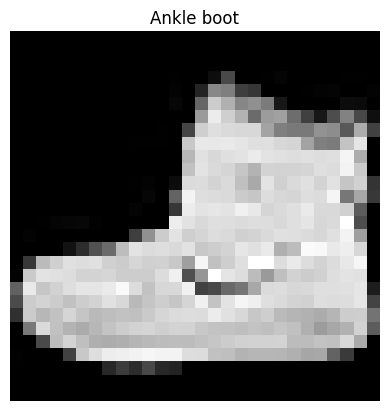

In [8]:
import matplotlib.pyplot as plt
image, label = train_data[0]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

In [9]:
#device = "cuda" if torch.cuda.is_available() else "cpu"

In [10]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)


In [11]:
train_feature_batch, train_label_batch = next(iter(train_dataloader))
train_feature_batch.shape, train_label_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image shape: torch.Size([1, 28, 28]), Label: 6, Class name: Shirt


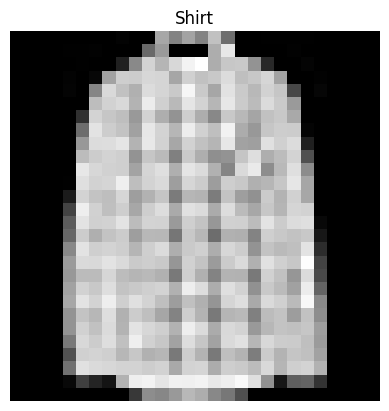

In [12]:
#torch.manual_seed(42)
random_idx = torch.randint(0, len(train_feature_batch), size=[1]).item()
img, label = train_feature_batch[random_idx], train_label_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)
print(f"Image shape: {img.shape}, Label: {label}, Class name: {class_names[label]}")

In [13]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # flatten the 28x28 into a single vector of 784
            nn.Linear(in_features=input_shape, out_features=hidden_units), # hidden layer
           # nn.ReLU(), # activation function for hidden layer
            nn.Linear(in_features=hidden_units, out_features=output_shape) # output layer
        )
    
    def forward(self, x):
        return self.layer_stack(x)

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [15]:
torch.manual_seed(42)
model_0 = FashionMNISTModelV0(input_shape=784, hidden_units=10, output_shape=10).to(device)
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [16]:
from helper_function import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [17]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [18]:
start_time = timer()
end_time = timer()
print_train_time(start_time, end_time, device="gpu")

Train time on gpu: 0.000 seconds


4.692699997121963e-05

In [19]:
from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_start_on_cpu = timer()

epoch = 3
for epoch in tqdm(range(epoch)):
    print(f"Epoch: {epoch}\n-------")
    train_loss = 0
    train_acc = 0

    # Set the model in training mode
    model_0.train()

    for batch, (X, y) in enumerate(train_dataloader):
        # Forward pass
        y_pred = model_0(X)
        
        # Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        
        # Calculate accuracy
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        
        # Zero gradients, perform backpropagation and update weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples.")  
        train_loss /= len(train_dataloader)

        #Testing  
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            test_pred = model_0(X_test)
            test_loss += loss_fn(test_pred, y_test).item()
            test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
    print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc/len(train_dataloader):.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%\n") 
train_time_end_on_cpu = timer() 
total_time_model_0 = print_train_time(train_time_start_on_cpu, train_time_end_on_cpu, device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [21]:
torch.manual_seed(42)
def eval_model(model: nn.Module, data_loader: DataLoader, loss_fn: nn.Module, accuracy_fn) -> dict:
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y).item()
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__, "model_loss": loss, "model_acc": acc}
model_0_results = eval_model(model=model_0, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 2.319064676571197,
 'model_acc': 10.852635782747603}

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [23]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # flatten the 28x28 into a single vector of 784
            nn.Linear(in_features=input_shape, out_features=hidden_units), # hidden layer
            nn.ReLU(), # activation function for hidden layer
            nn.Linear(in_features=hidden_units, out_features=output_shape), # output layer
            nn.ReLU()
        )
    
    def forward(self, x):
        return self.layer_stack(x)

In [24]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784, hidden_units=10, output_shape=10).to(device)


In [25]:
next(model_1.parameters()).device

device(type='cuda', index=0)

In [26]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [27]:
def train_step(model: nn.Module,
              data_loader: DataLoader,
              loss_fn: nn.Module,
              optimizer: torch.optim.Optimizer,
              accuracy_fn) -> dict:
    train_loss, train_acc = 0, 0
    model.train()
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    return {"model_name": model.__class__.__name__, "train_loss": train_loss, "train_acc": train_acc}

In [28]:
def test_step(model: nn.Module,
             data_loader: DataLoader,
             loss_fn: nn.Module,
             accuracy_fn) -> dict:
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y).item()
            acc += accuracy_fn(y_true=y.cpu(), y_pred=y_pred.argmax(dim=1).cpu())
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__, "model_loss": loss, "model_acc": acc}

In [29]:
epoch = 3
for epoch in tqdm(range(epoch)):
    train_step_results = train_step(model=model_1,
                                  data_loader=train_dataloader,
                                  loss_fn=loss,
                                  optimizer=optimizer,
                                  accuracy_fn=accuracy_fn)
    test_step_results = test_step(model=model_1,
                                data_loader=test_dataloader,
                                loss_fn=loss,
                                accuracy_fn=accuracy_fn)
    print(f"Train loss: {train_step_results['train_loss']:.5f} | Train acc: {train_step_results['train_acc']:.2f}% | Test loss: {test_step_results['model_loss']:.5f} | Test acc: {test_step_results['model_acc']:.2f}%\n")

  0%|          | 0/3 [00:00<?, ?it/s]

Train loss: 1.05878 | Train acc: 62.19% | Test loss: 0.99506 | Test acc: 64.13%

Train loss: 0.91331 | Train acc: 66.40% | Test loss: 0.90508 | Test acc: 66.86%

Train loss: 0.87982 | Train acc: 67.24% | Test loss: 0.89476 | Test acc: 66.46%



In [30]:
model_1_results = eval_model(model=model_1,
            data_loader=test_dataloader, loss_fn=loss, accuracy_fn=accuracy_fn)

In [31]:
class FashionMNISTV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, out_shape:int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7, out_features=out_shape)
        )
    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x
    

In [32]:
torch.manual_seed(42)
model_2 = FashionMNISTV2(input_shape=1,
                        hidden_units=10,
                        out_shape=10).to(device)

In [33]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

In [34]:
epoch=3
for epoch in tqdm(range(epoch)):
    print(f"Epoch: {epoch}\n-------" )
    train_step_results = train_step(model=model_2,  
                                data_loader=train_dataloader,  
                                loss_fn=loss_fn,  
                                optimizer=optimizer,  
                                accuracy_fn=accuracy_fn)
    test_step_results = test_step(model=model_2,
                                data_loader=test_dataloader,  
                                loss_fn=loss_fn,  
                                accuracy_fn=accuracy_fn)
    print(f"Train loss: {train_step_results['train_loss']:.5f} | Train acc: {train_step_results['train_acc']:.2f}% | Test loss: {test_step_results['model_loss']:.5f} | Test acc: {test_step_results['model_acc']:.2f}%\n")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.57762 | Train acc: 79.14% | Test loss: 0.39924 | Test acc: 84.96%

Epoch: 1
-------
Train loss: 0.35312 | Train acc: 87.28% | Test loss: 0.34677 | Test acc: 87.39%

Epoch: 2
-------
Train loss: 0.31342 | Train acc: 88.62% | Test loss: 0.34065 | Test acc: 87.59%



In [35]:
model_2_results = eval_model(model=model_2,
                            data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn)
model_2_results,model_0_results

({'model_name': 'FashionMNISTV2',
  'model_loss': 0.3406523158565497,
  'model_acc': 87.58985623003196},
 {'model_name': 'FashionMNISTModelV0',
  'model_loss': 2.319064676571197,
  'model_acc': 10.852635782747603})

In [36]:
def make_predictions(model: nn.Module,
                    data: list,
                    device: torch.device = device):
    
    pred_probs = []
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for sample in data:
             sample = torch.unsqueeze(sample, dim=0).to(device)
             pred_logits = model(sample)
             pred_prob = torch.softmax(pred_logits.squeeze(), dim=0)
             pred_probs.append(pred_prob.cpu())

        return torch.stack(pred_probs)

In [37]:
import random 
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

In [38]:
pred_probs = make_predictions(model=model_2, data=test_samples)

In [39]:
pred_clss = pred_probs.argmax(dim=1)

In [40]:
pred_clss

tensor([5, 0, 7, 2, 3, 0, 4, 7, 1])

In [41]:
test_labels

[5, 1, 7, 4, 3, 0, 4, 7, 1]

Text(0.5, 1.0, 'True label: Sandal | Predicted: Sandal')

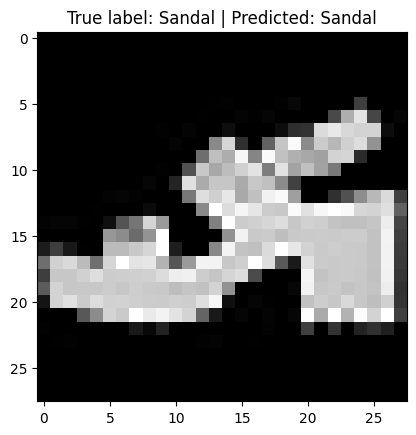

In [43]:
plt.imshow(test_samples[0].squeeze(), cmap="gray")
plt.title(f"True label: {class_names[test_labels[0]]} | Predicted: {class_names[pred_clss[0]]}")

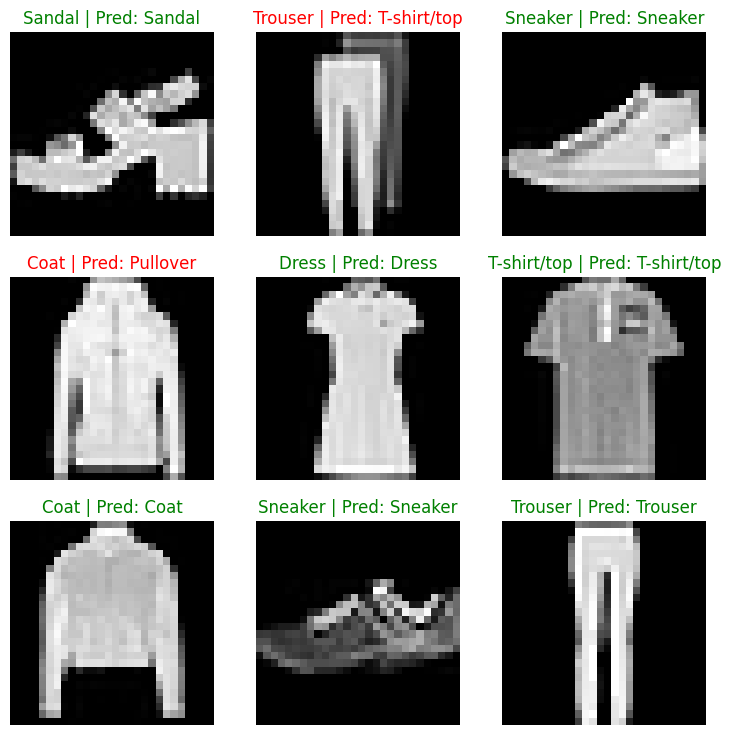

In [50]:
plt.figure(figsize=(9, 9))
nrowes = 3 
ncols = 3
for i, sample in enumerate(test_samples):
    plt.subplot(nrowes, ncols, i+1)
    plt.imshow(sample.squeeze(), cmap="gray")
    #plt.title(f"True: {class_names[test_labels[i]]} | Pred: {class_names[pred_clss[i]]}")
    plt.axis(False)
    if class_names[test_labels[i]]==class_names[pred_clss[i]]:
        plt.title(f"{class_names[test_labels[i]]} | Pred: {class_names[pred_clss[i]]}", color="green")
    else:
        plt.title(f"{class_names[test_labels[i]]} | Pred: {class_names[pred_clss[i]]}", color="red")

In [53]:
y_preds = []
model_2.eval()
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions..."):
        X, y = X.to(device), y.to(device)
        y_logits = model_2(X)
        y_pred = torch.softmax(y_logits.squeeze(),dim =0).argmax( dim=1)
        y_preds.append(y_pred.cpu())

#print(y_preds)
y_pred_tensor = torch.cat(y_preds, dim=0)
y_pred_tensor.shape,
y_pred_tensor[:10]


Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [57]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

In [56]:
!pip install mlxtend

  Obtaining dependency information for mlxtend from https://files.pythonhosted.org/packages/a9/f9/f62b6c3bd08e1269d9bca9aabe0d990a7c3ffbfbcc495135ad0b59ce860b/mlxtend-0.24.0-py3-none-any.whl.metadata
  Obtaining dependency information for scipy>=1.16.3 from https://files.pythonhosted.org/packages/09/7d/af933f0f6e0767995b4e2d705a0665e454d1c19402aa7e895de3951ebb04/scipy-1.17.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.6 MB/s eta 0:00:00
  Obtaining dependency information for numpy>=2.3.5 from https://files.pythonhosted.org/packages/cf/c5/9fcb7e0e69cef59cf10c746b84f7d58b08bc66a6b7d459783c5a4f6101a6/numpy-2.4.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for pandas>=2.3.3 from https://files.pythonhosted.org/packages/20/17/ec40d981705654853726e7ac9aea9ddbb4a5d9cf54d8472222f4f3de06c2/pandas-3.0.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x

In [59]:
import mlxtend
print(mlxtend.__version__)


0.24.0


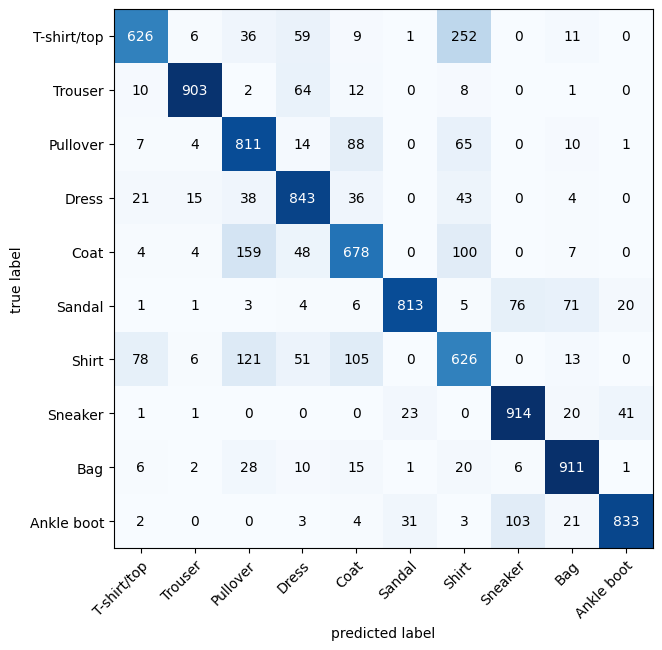

In [65]:
confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
confmat_tensor = confmat(preds=y_pred_tensor, target=test_data.targets)

fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.numpy(),
                                class_names=class_names,
                                figsize=(10, 7))


In [66]:
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "fashion_mnist_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)
